<a href="https://colab.research.google.com/github/Shahad-Hossain/nasa-image-enhancement/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from numpy.lib.stride_tricks import sliding_window_view

from google.colab import drive

In [ ]:
def show(image: np.ndarray, cmap=None, title=None):
  try:
    plt.imshow(image, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
  except Exception as e:
    return ValueError(f"Unknown error occured: {e}")

In [ ]:
def gray(r: float, g: float, b: float) -> float:
  return (0.2989 * r + 0.5870 * g + 0.1140 * b)

def grayscale(image: np.ndarray) -> np.ndarray:
  return gray(image[:, :, 0], image[:, :, 1], image[:, :, 2]).astype(np.uint8)

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def saveImageToDrive(filename: str, driveFolder: str = 'CSC475/Homework6') -> None:
  try:
    imagePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"
    image = cv.imread(imagePath)

    if image is None:
        print("Image not found.")
        return

    cv.imwrite(imagePath, image)
    print(f'Image successfully saved to: {imagePath}')

  except Exception as e:
    print(f'Error saving image to Drive: {e}')


def loadImageFromDrive(filename: str, driveFolder: str = 'CSC475/Homework6') -> np.ndarray:
  """
  Loads an image from Google Drive into a NumPy array.
  """
  try:
    filePath = f"/content/drive/MyDrive/{driveFolder}/{filename}"

    loadedImgBgr = cv.imread(filePath)

    print(f'Image successfully loaded from: {filePath}')
    return cv.cvtColor(loadedImgBgr, cv.COLOR_BGR2GRAY)

  except Exception as e:
    print(f'Error loading image from Drive: {e}')
    return None

In [ ]:
matrix = np.ones((13, 13), dtype=int)

print(matrix)

[[1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1]]


Image successfully loaded from: /content/drive/MyDrive/CSC475/Homework6/image 5.jpg


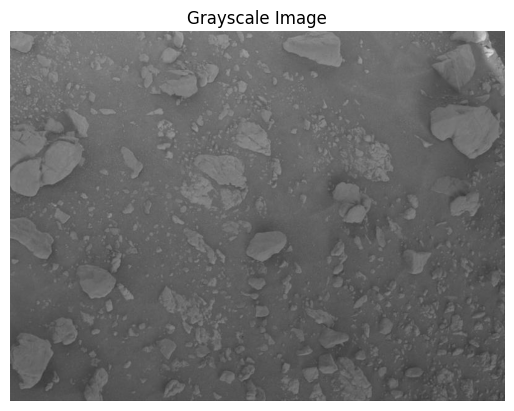

In [ ]:
imgName = f"image 5.jpg"

marsImage = loadImageFromDrive(imgName)

show(marsImage, cmap="gray", title="Grayscale Image")

In [ ]:
# helper functions to show differences and showcase results
def complement(image: np.ndarray) -> np.ndarray:
    return 255 - image

def difference(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    diff = a.astype(np.int16) - b.astype(np.int16)
    return np.clip(diff, 0, 255).astype(np.uint8)

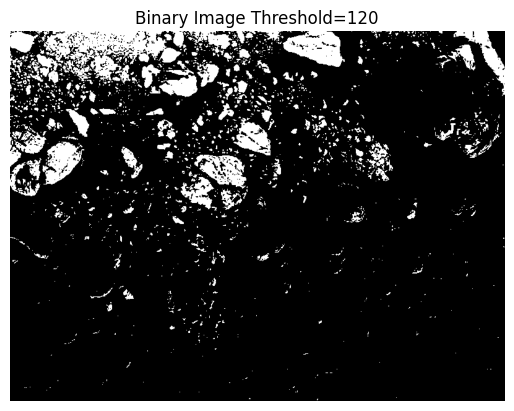

In [ ]:
# Convert to binary image

# def binImage(image: np.ndarray) -> np.ndarray:
#   if image.ndim != 2: raise ValueError("Image is not grayscale")
#   height, width = image.shape
#   threshold = 175

#   output = np.zeros((height, width), dtype=np.uint8)

#   for h in range(height):
#     for w in range(width):
#       if image[h][w] >= threshold:
#         output[h][w] = 255
#       else:
#         output[h][w] = 0

#   return output

def binImage(image: np.ndarray, threshold: float) -> np.ndarray:
    return (image >= threshold).astype(np.uint8) * 255

threshold = 120
show(binImage(marsImage, threshold), cmap="gray", title=f"Binary Image Threshold={threshold}")
binMarsImage = binImage(marsImage, threshold=threshold)

In [ ]:
binMarsImage = binImage(marsImage, threshold=threshold)

In [ ]:
# def dilation(image, k: int) -> np.ndarray:
#     if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

#     output = np.zeros_like(image)
#     pad = k // 2
#     padded = np.pad(image, pad, mode="reflect")
#     neighborhoods = sliding_window_view(padded, (k, k))

#     height, width = neighborhoods.shape[0:2]

#     for i in range(height):
#       for j in range(width):
#         neighborhood = neighborhoods[i, j]
#         output[i, j] = np.max(neighborhood)

#     return output

# big gpt optimization
def dilation(image: np.ndarray, k: int) -> np.ndarray:
    if k % 2 == 0:
        raise ValueError(f"k: {k} must be odd")

    pad = k // 2
    padded = np.pad(image, pad, mode="reflect")
    neighborhoods = sliding_window_view(padded, (k, k))
    return np.max(neighborhoods, axis=(2, 3))

In [ ]:
# def erosion(image, k: int) -> np.ndarray:
#     if k % 2 == 0: raise ValueError(f"k: {k} must be odd")

#     output = np.zeros_like(image)
#     pad = k // 2
#     padded = np.pad(image, pad, mode="reflect")
#     neighborhoods = sliding_window_view(padded, (k, k))

#     height, width = neighborhoods.shape[0:2]

#     for i in range(height):
#       for j in range(width):
#         neighborhood = neighborhoods[i, j]
#         output[i, j] = np.min(neighborhood)

#     return output

# big gpt optimization
def erosion(image: np.ndarray, k: int) -> np.ndarray:
    if k % 2 == 0:
        raise ValueError(f"k: {k} must be odd")

    pad = k // 2
    padded = np.pad(image, pad, mode="reflect")
    neighborhoods = sliding_window_view(padded, (k, k))
    return np.min(neighborhoods, axis=(2, 3))

In [ ]:
# opening is just erosion --> dilation
# closing is just dilation --> erosion
# morphological gradient = dilation - erosion
def morphologicalGrad(image: np.ndarray, k: int = 3) -> np.ndarray:
    d = dilation(image, k).astype(np.int16)
    e = erosion(image, k).astype(np.int16)
    return np.clip(d - e, 0, 255).astype(np.uint8)

def closing(image: np.ndarray, k: int = 3) -> np.ndarray:
    return erosion(dilation(image, k), k)

def opening(image: np.ndarray, k: int = 3) -> np.ndarray:
    return dilation(erosion(image, k), k)

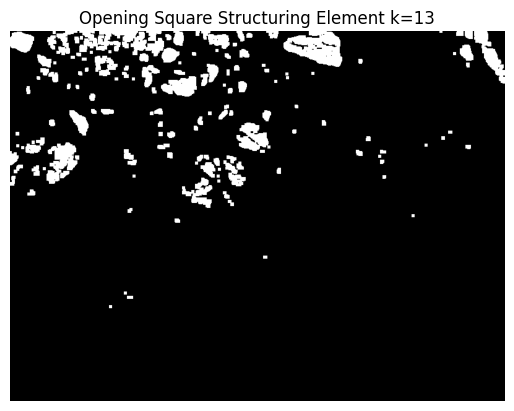

In [ ]:
show(opening(marsImage, k=5), cmap="gray", title=f"Opening Square Structuring Element k={13}")

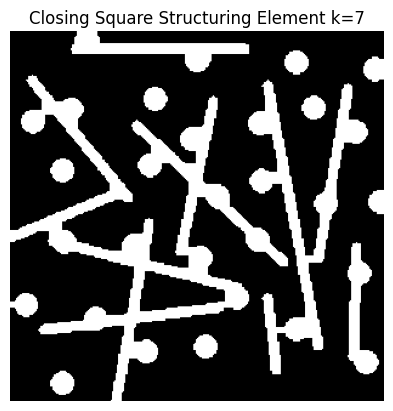

In [ ]:
k = 7
show(closing(marsImage, k=k), cmap="gray", title=f"Closing Square Structuring Element k={k}")

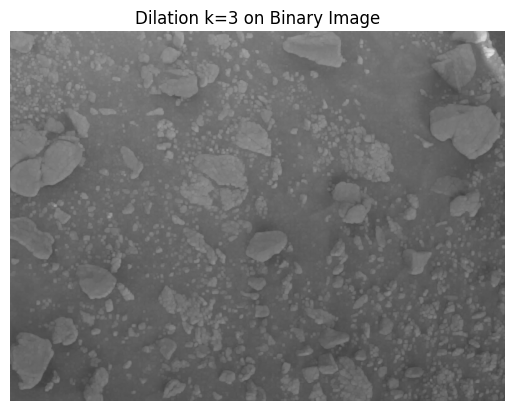

In [ ]:
show(dilation(marsImage, k=3), cmap="gray", title=f"Dilation k={3} on Binary Image")

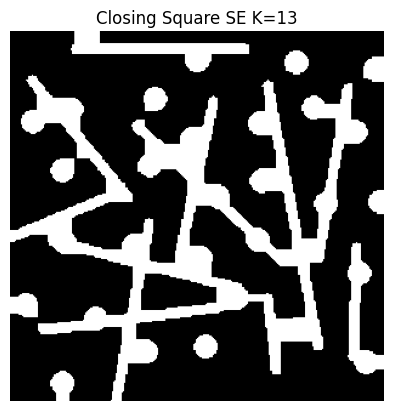

In [ ]:
show(closing(marsImage, k=13), cmap="gray", title=f"Closing Square SE K={13}")

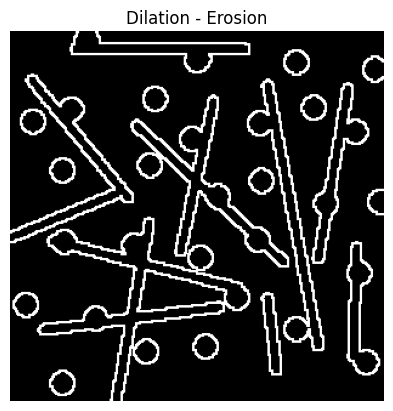

In [ ]:
show(morphologicalGrad(marsImage), cmap="gray", title="Dilation - Erosion")

In [ ]:
def disk(radius: int) -> np.ndarray:
    size = 2*radius + 1
    se = np.zeros((size, size), dtype=np.uint8)
    c = radius

    for i in range(size):
        for j in range(size):
            if (i-c)**2 + (j-c)**2 <= radius**2:
                se[i, j] = 1

    return se

square3 = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.uint8)

cross3 = np.array([
    [0,1,0],
    [1,1,1],
    [0,1,0]
], dtype=np.uint8)

diamond5 = np.array([
    [0,0,1,0,0],
    [0,1,1,1,0],
    [1,1,1,1,1],
    [0,1,1,1,0],
    [0,0,1,0,0]
], dtype=np.uint8)

In [ ]:
print(disk(7))

[[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]]


In [ ]:
# thank you big gpt
def dilation_se(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    kh, kw = se.shape
    pad_h, pad_w = kh // 2, kw // 2
    image = image.astype(np.float64)
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    neighborhoods = sliding_window_view(padded, (kh, kw))
    masked = np.where(se == 1, neighborhoods, -np.inf)
    return np.max(masked, axis=(2, 3))

def erosion_se(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    kh, kw = se.shape
    pad_h, pad_w = kh // 2, kw // 2
    image = image.astype(np.float64)
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode="reflect")
    neighborhoods = sliding_window_view(padded, (kh, kw))
    masked = np.where(se == 1, neighborhoods, np.inf)
    return np.min(masked, axis=(2, 3))

In [ ]:
def morphologicalGrad_se(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    d = dilation_se(image, se).astype(np.int16)
    e = erosion_se(image, se).astype(np.int16)
    return np.clip(d - e, 0, 255).astype(np.uint8)

def opening_se(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    return dilation_se(erosion_se(image, se), se)

def closing_se(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    return erosion_se(dilation_se(image, se), se)

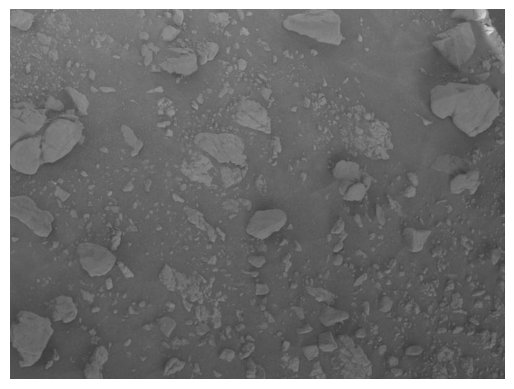

In [ ]:
show(marsImage, cmap="gray")

In [ ]:
show(dilation_se(marsImage, se=disk(k)), cmap="gray")

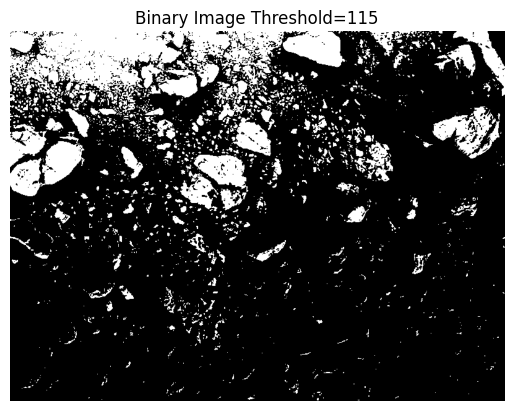

In [ ]:
def binImage(image: np.ndarray, threshold: float) -> np.ndarray:
    return (image >= threshold).astype(np.uint8) * 255

threshold = 115
show(binImage(marsImage, threshold), cmap="gray", title=f"Binary Image Threshold={threshold}")
binMarsImage = binImage(marsImage, threshold=threshold)

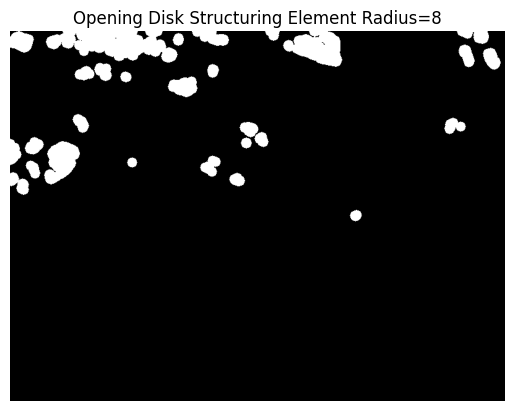

In [ ]:
k = 8
show(opening_se(binMarsImage, se=disk(k)), cmap="gray", title=f"Opening Disk Structuring Element Radius={k}")

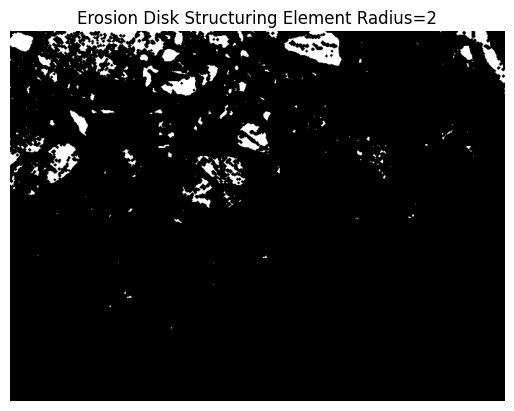

In [ ]:
k = 2
show(erosion_se(marsImage, se=disk(k)), cmap="gray", title=f"Erosion Disk Structuring Element Radius={k}")

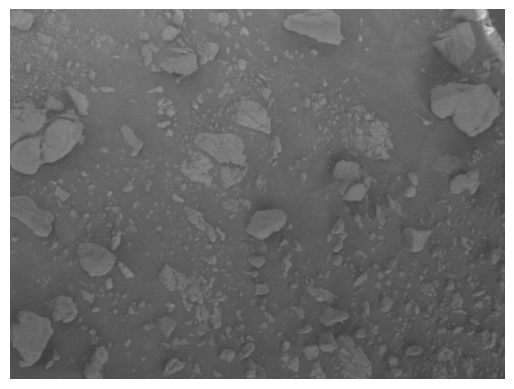

In [ ]:
blur = cv.GaussianBlur(marsImage, (3,3), 0)
show(blur, cmap="gray")

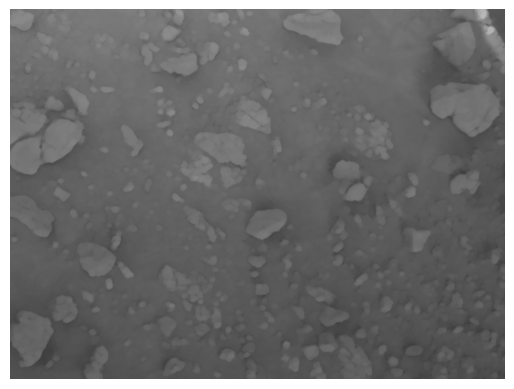

In [ ]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7,7))
opened = cv.morphologyEx(blur, cv.MORPH_OPEN, kernel)
show(opened, cmap="gray")

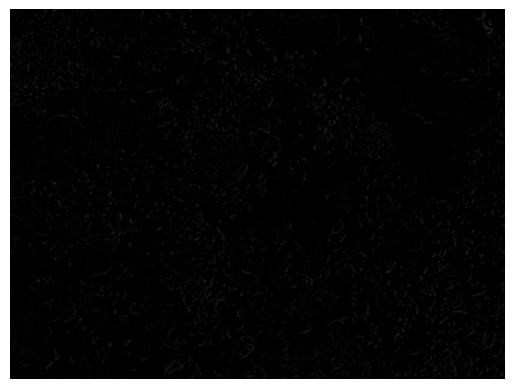

In [ ]:
tophat = cv.subtract(blur, opened)
show(tophat, cmap="gray")

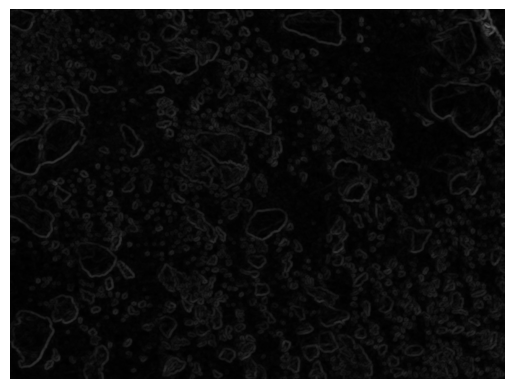

In [ ]:
kernel2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
gradient = cv.morphologyEx(blur, cv.MORPH_GRADIENT, kernel2)

show(gradient, cmap="gray")

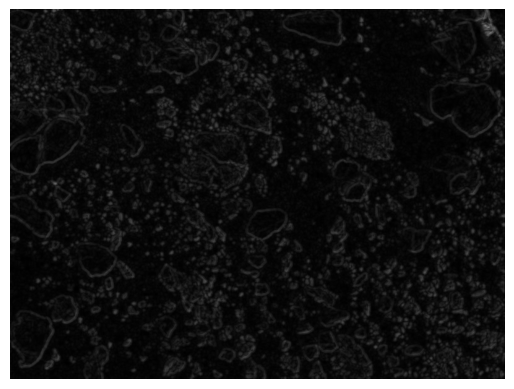

In [ ]:
combined = cv.addWeighted(tophat, 1.5, gradient, 1.0, 0)
show(combined, cmap="gray")

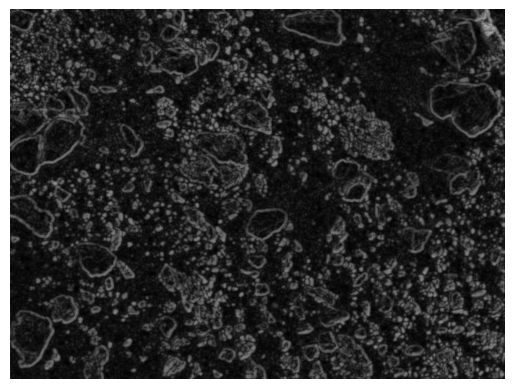

In [ ]:
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(combined)
show(enhanced, cmap="gray")

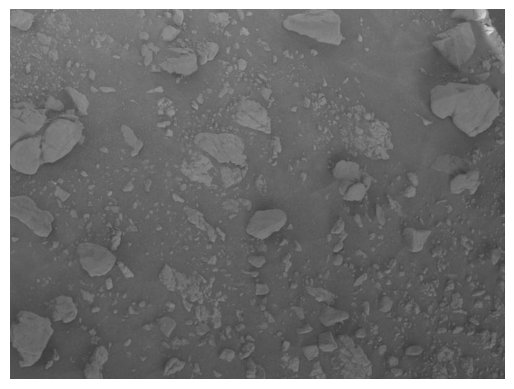

In [ ]:
show(marsImage, cmap="gray")

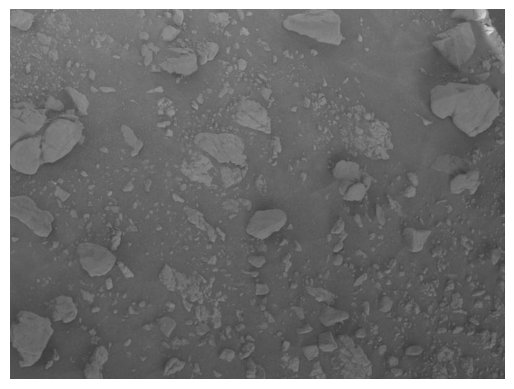

In [ ]:
show(marsImage, cmap="gray")

In [ ]:
def tophat_to_binary(tophatImage):
    _, binaryMask = cv.threshold(
        tophatImage, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
    )
    return binaryMask

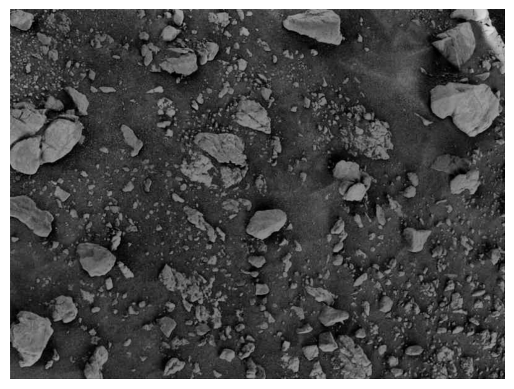

In [ ]:
# 1. Enhance local contrast first so the rocks stand out from the sand
# We use CLAHE here just to prepare the image for masking
clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
contrast_boosted = clahe.apply(marsImage)

# 2. Morphological Top-Hat Transform
# This extracts the "bright" rocks that are smaller than the kernel size
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (150, 150))
tophat = cv.morphologyEx(contrast_boosted, cv.MORPH_TOPHAT, kernel)

show(tophat, cmap="gray")

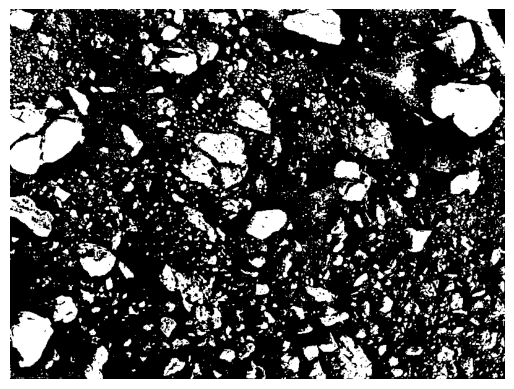

In [ ]:
def tophat_to_binary(tophatImage):
    _, binaryMask = cv.threshold(
        tophatImage, 15, 255, cv.THRESH_BINARY + cv.THRESH_OTSU
    )
    return binaryMask

mask = tophat_to_binary(tophat)
show(tophat_to_binary(tophat), cmap="gray")

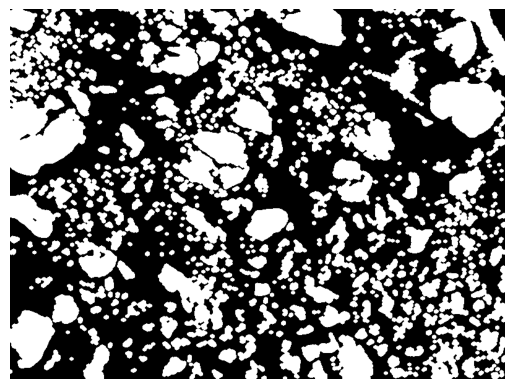

In [ ]:
def clean_rock_mask(binaryMask):
    openKernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    closeKernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
    dilateKernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))

    cleaned = cv.morphologyEx(binaryMask, cv.MORPH_OPEN, openKernel)
    cleaned = cv.morphologyEx(cleaned, cv.MORPH_CLOSE, closeKernel)
    cleaned = cv.dilate(cleaned, dilateKernel, iterations=1)

    return cleaned

cleanedMask = clean_rock_mask(mask)
show(cleanedMask, cmap="gray")

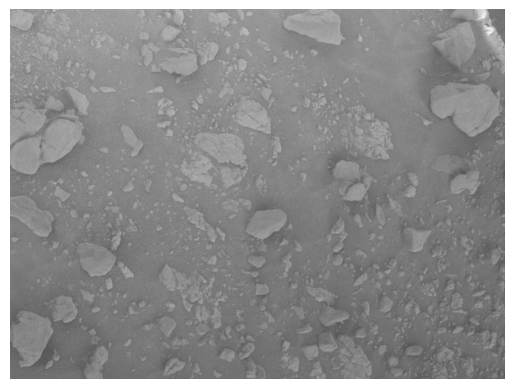

In [ ]:
def enhance_rocks_only(originalImage, rockMask):
    imageFloat = originalImage.astype(np.float32) / 255.0

    logImage = np.log1p(imageFloat)
    logImage = logImage / logImage.max()
    logImage = (logImage * 255).astype(np.uint8)

    return logImage

show(enhance_rocks_only(marsImage, cleanedMask), cmap="gray")

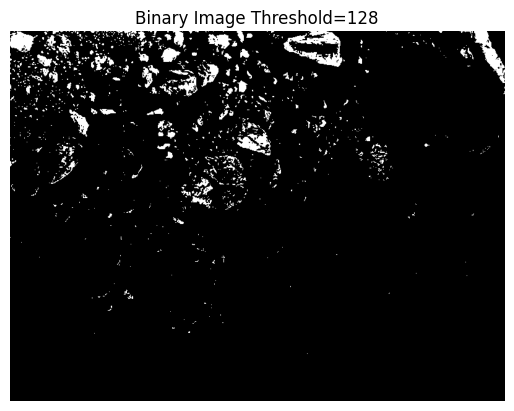

In [ ]:
threshold = 128
show(binImage(marsImage, threshold), cmap="gray", title=f"Binary Image Threshold={threshold}")
binMarsImage = binImage(marsImage, threshold=threshold)